# Channels at continuous positions

> Paths ray-traced at anchor points, moved to wherever a robot is: why moving them matters, and how far apart the anchors can be.

An access point at the ceiling of a room, and a robot driving through it. The channel is "ray-traced" at anchor
points. Here it's an exact image-method model: a line-of-sight path, a reflection off each of two walls and one
double reflection. With a real scene, the anchors would come from `trace_paths` and Sionna RT.

Between anchors, the robot's channel can be taken in three ways:

* **nearest anchor:** the channel of the closest anchor, as it is.
* **plane waves:** the nearest anchor's paths, with their delays shifted to first order.
* **moved paths:** what `RayTracedPathsFading` does. Each path is moved as a line from an image of the
  transmitter.

The channel's phase turns a full circle every wavelength (5.8 cm at 5.18 GHz), so it changes quickly as the robot
moves.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np

from comm_core import *

In [ ]:
C, F = 299_792_458.0, 5.18e9
SUBCARRIERS = (np.arange(52) - 25.5) * 312.5e3
AP = np.array([0.0, 0.0, 2.4])
WALLS = [(1, 3.0, -0.6), (0, -8.0, -0.5)]                   # (axis, coordinate, reflection coefficient)

def mirror(axis, c):
    m = np.eye(3); m[axis, axis] = -1
    return m, 2 * c * np.eye(3)[axis]

def room_paths(tx, rx):
    "Exact paths: line of sight, one reflection off each wall, and the double reflection (image method)."
    images = [(tx, 1.0, np.eye(3))]
    for axis, c, gamma in WALLS:
        m, shift = mirror(axis, c)
        images.append((m @ tx + shift, gamma, m))
    (a1, c1, g1), (a2, c2, g2) = WALLS
    m1, s1 = mirror(a1, c1); m2, s2 = mirror(a2, c2)
    images.append((m2 @ (m1 @ tx + s1) + s2, g1 * g2, m2 @ m1))
    a, tau, u_tx, u_rx = [], [], [], []
    for source, gain, m in images:
        v = rx - source; L = np.linalg.norm(v)
        a.append(gain * C / F / (4 * np.pi * L) * np.exp(-2j * np.pi * F * L / C))
        tau.append(L / C); u_rx.append(-v / L); u_tx.append(m.T @ (v / L))
    return np.array(a), np.array(tau), np.array(u_tx), np.array(u_rx)

def exact(rx, f=np.zeros(1)):
    a, tau, _, _ = room_paths(AP, np.asarray(rx, float))
    return np.exp(-2j * np.pi * np.outer(f, tau)) @ a

def fading(spacing):
    anchors = grid_points((-7.0, -3.0), (-2.0, 1.0), spacing, height=0.4)
    traced = [room_paths(AP, p) for p in anchors]
    arrays = [np.array([t[k] for t in traced])[None] for k in range(4)]
    return RayTracedPathsFading(AP[None], anchors, *arrays, frequency=F, subcarriers=SUBCARRIERS, node_positions={'ap': AP})

def plane_waves(f, s='ap', r='robot'):
    a, tau, u_dep, d_dep, u_arr, d_arr = f._paths(s, r)
    dtau = -(u_dep @ d_dep + u_arr @ d_arr) / C
    return np.exp(-2j * np.pi * np.outer(f.subcarriers, tau + dtau)) @ (a * np.exp(-2j * np.pi * F * dtau))

def nearest(f, s='ap', r='robot'):
    j = np.argmin(((f.rx_points - f.node_positions[r]) ** 2).sum(-1))
    return np.exp(-2j * np.pi * np.outer(f.subcarriers, f.tau[0, j])) @ f.a[0, j]

route = np.stack([np.linspace(-6.5, -2.5, 801), np.linspace(-2.5, 0.5, 801), np.full(801, 0.4)], 1)   # 5 m, a point every 6 mm
along = np.r_[0, np.cumsum(np.linalg.norm(np.diff(route, axis=0), axis=1))]

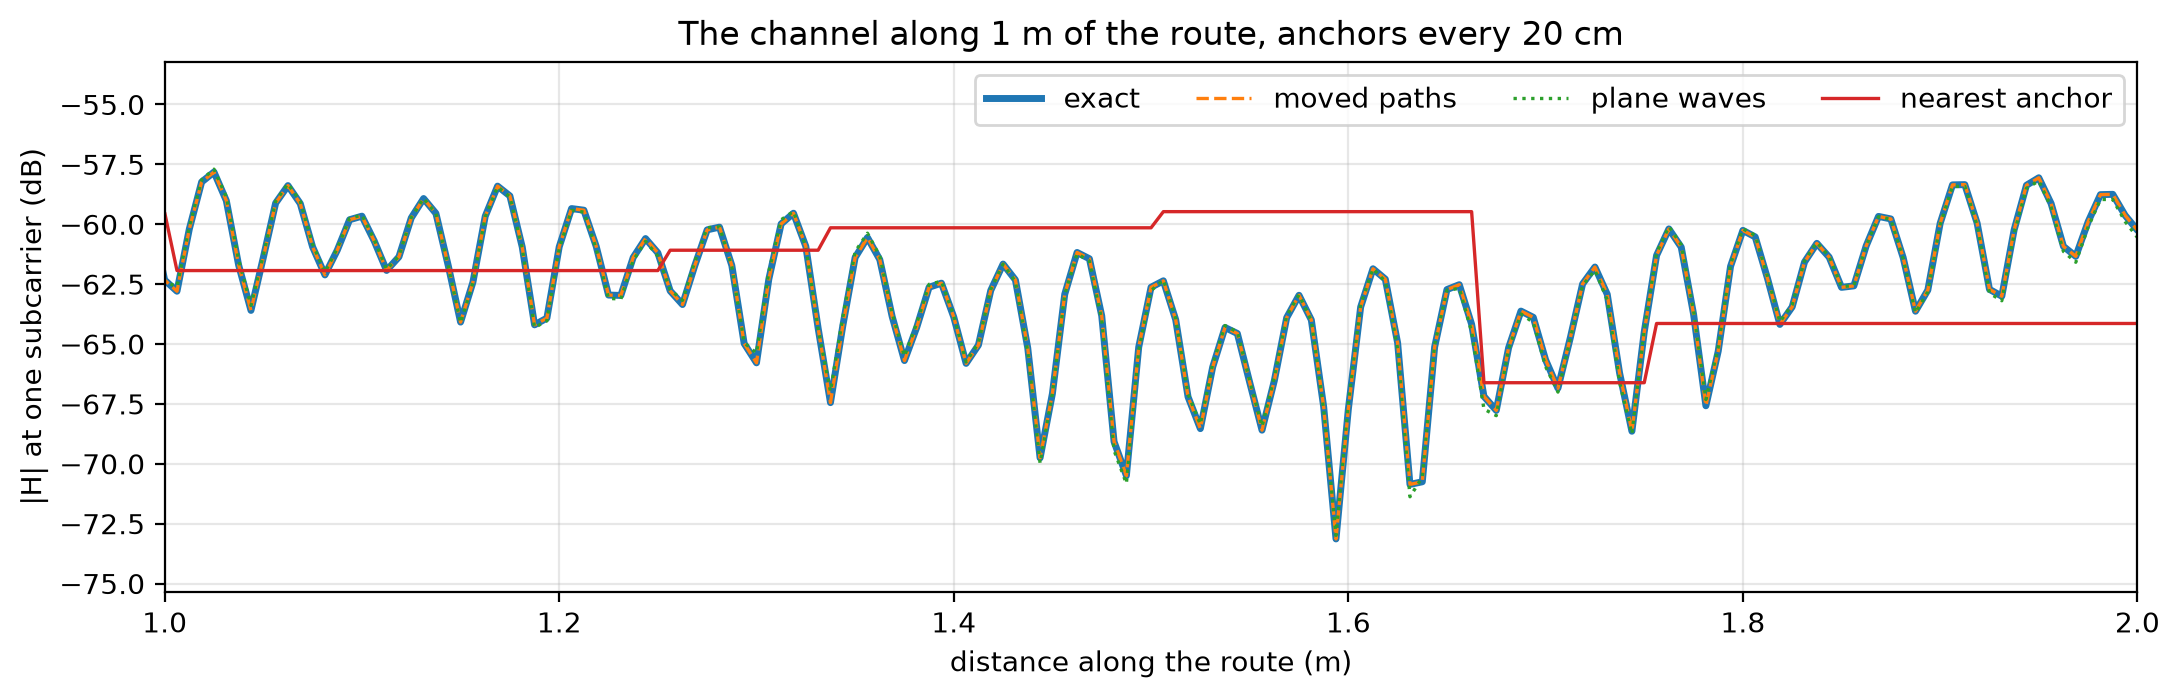

In [ ]:
f20 = fading(0.20)                                          # anchors every 20 cm
center = len(SUBCARRIERS) // 2
curves = {'exact': [], 'moved paths': [], 'plane waves': [], 'nearest anchor': []}
for p in route:
    f20.set_positions({'robot': p})
    curves['exact'].append(exact(p, SUBCARRIERS)[center])
    curves['moved paths'].append(f20.cfr('ap', 'robot')[center])
    curves['plane waves'].append(plane_waves(f20)[center])
    curves['nearest anchor'].append(nearest(f20)[center])
fig, ax = plt.subplots(figsize=(11, 3.6))
for name, h in curves.items():
    ax.plot(along, 20 * np.log10(np.abs(h)), lw=2.5 if name == 'exact' else 1.2,
            ls={'exact': '-', 'moved paths': '--', 'plane waves': ':', 'nearest anchor': '-'}[name], label=name)
ax.set(xlabel='distance along the route (m)', ylabel='|H| at one subcarrier (dB)', xlim=(1.0, 2.0),
       title='The channel along 1 m of the route, anchors every 20 cm')
ax.grid(alpha=0.3); ax.legend(ncol=4)
plt.tight_layout()

The nearest anchor's channel jumps from anchor to anchor and misses the fades in between: the deep dips, where the
paths cancel. Plane waves follow it close to the anchors and drift between them. Moved paths follow the exact
channel.

How the error grows with the spacing of the anchors (normalized mean squared error over the route and the 52
subcarriers):

{'moved paths': [np.float64(-263.7), np.float64(-263.1), np.float64(-263.2), np.float64(-262.6), np.float64(-262.3)], 'plane waves': [np.float64(-46.7), np.float64(-35.5), np.float64(-23.8), np.float64(-7.9), np.float64(0.7)], 'nearest anchor': [np.float64(1.6), np.float64(3.7), np.float64(3.0), np.float64(2.5), np.float64(2.7)]}


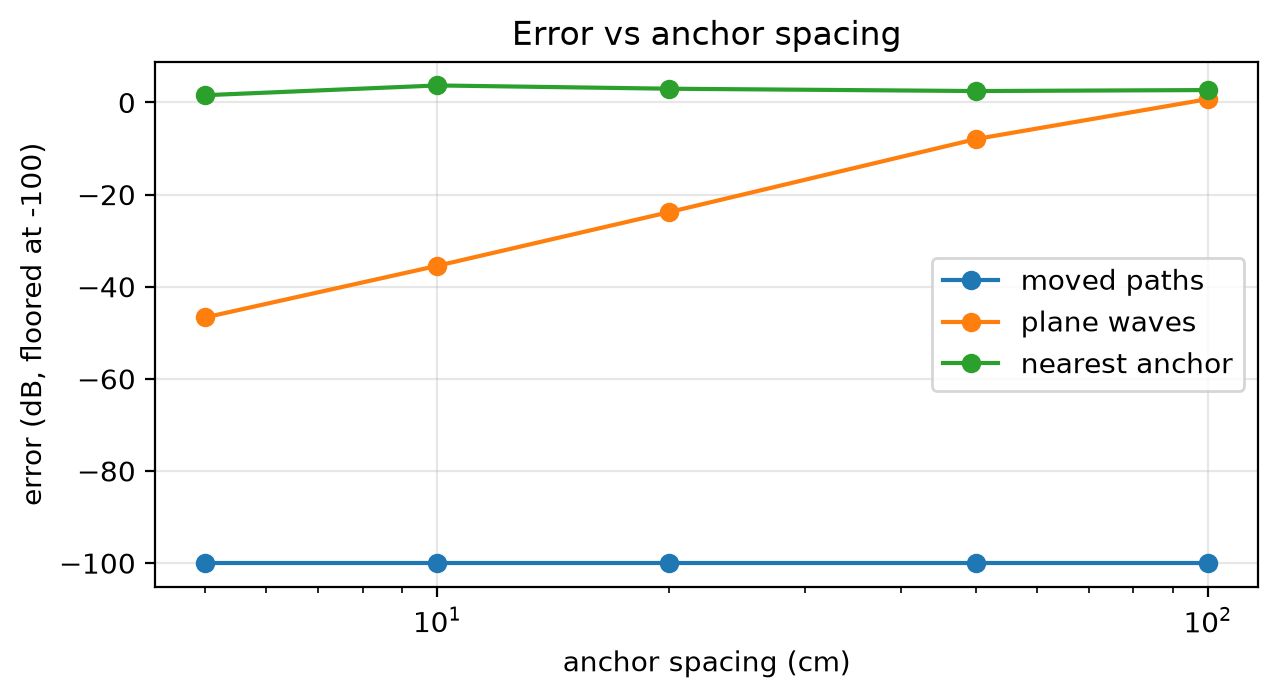

In [ ]:
spacings = [0.05, 0.1, 0.2, 0.5, 1.0]
errors = {'moved paths': [], 'plane waves': [], 'nearest anchor': []}
truth = np.array([exact(p, SUBCARRIERS) for p in route[::4]])
for spacing in spacings:
    f = fading(spacing)
    est = {k: [] for k in errors}
    for p in route[::4]:
        f.set_positions({'robot': p})
        est['moved paths'].append(f.cfr('ap', 'robot')); est['plane waves'].append(plane_waves(f)); est['nearest anchor'].append(nearest(f))
    for k in errors:
        errors[k].append(10 * np.log10(np.sum(np.abs(np.array(est[k]) - truth) ** 2) / np.sum(np.abs(truth) ** 2)))
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for k, e in errors.items():
    ax.plot(np.array(spacings) * 100, np.maximum(e, -100), 'o-', label=k)
ax.set(xscale='log', xlabel='anchor spacing (cm)', ylabel='error (dB, floored at -100)', title='Error vs anchor spacing')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
print({k: [round(x, 1) for x in e] for k, e in errors.items()})
assert all(e < -60 for e in errors['moved paths']) and all(e > -5 for e in errors['nearest anchor'])

* **In this room, moved paths are essentially exact at any spacing.** Its walls are flat, the access point is
  fixed and no path appears or disappears.
* **In real scenes, the limit is paths appearing or disappearing between anchors.** The validation against
  Sionna RT in `sionna_rt` measures it: −47 to −63 dB with a fixed access point, for anchors up to 50 cm apart.
* **The anchors can be far apart.** Moving the paths, rather than taking the nearest anchor, is what allows it.

Over the 52 subcarriers, the channel along the route is frequency-selective, so different subcarriers fade at
different places:

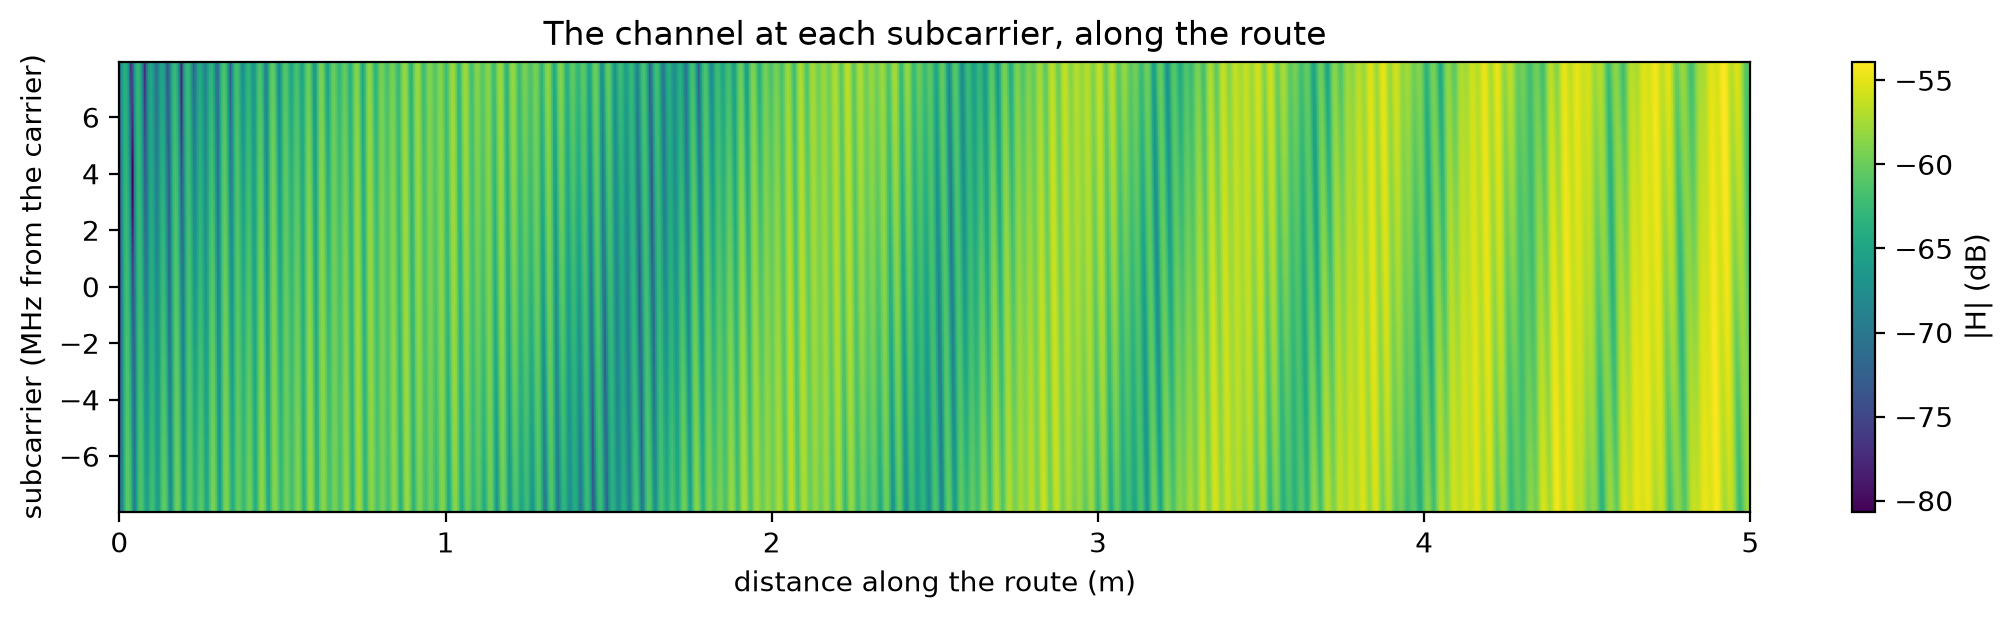

In [ ]:
f5 = fading(0.05)
grid = []
for p in route:
    f5.set_positions({'robot': p})
    grid.append(20 * np.log10(np.abs(f5.cfr('ap', 'robot'))))
fig, ax = plt.subplots(figsize=(11, 3.2))
im = ax.imshow(np.array(grid).T, aspect='auto', origin='lower', extent=[along[0], along[-1], SUBCARRIERS[0] / 1e6, SUBCARRIERS[-1] / 1e6], cmap='viridis')
fig.colorbar(im, ax=ax, label='|H| (dB)')
ax.set(xlabel='distance along the route (m)', ylabel='subcarrier (MHz from the carrier)', title='The channel at each subcarrier, along the route')
plt.tight_layout()